In [36]:
import json
from datetime import timezone
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from bisect import bisect_right  
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.dates as mdates
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize

import numpy as np

import sys, importlib
import obspy
from obspy import read, UTCDateTime, Stream
from obspy.core.util import AttribDict
from obspy.geodetics.base import gps2dist_azimuth
from obspy.imaging.cm import obspy_sequential
from obspy.signal.array_analysis import array_processing
from obspy.taup import TauPyModel
from obspy.geodetics import locations2degrees

In [41]:
# --- helpers ---
HELPERS_DIR = Path("/home/elizabeth/soft/src/QuickQuake/quickquake").resolve()
if str(HELPERS_DIR) not in sys.path:
    sys.path.insert(0, str(HELPERS_DIR))

import qq_helpers as h
importlib.reload(h)
print("helpers:", h.__file__)

# --- paths ---
DATA_ROOT = Path("/home/elizabeth/soft/src/QuickQuake/data").resolve()

CATALOG_CSV   = DATA_ROOT / "merged/output/GAMMA_hypodd_catalog.csv"
PICKS_CSV     = DATA_ROOT / "merged/input/GAMMA_picks_cleaned.csv"
STATIONS_JSON = DATA_ROOT / "merged/input/GAMMA_station_list.json"

INDEX_PATH = Path("/home/elizabeth/soft/src/QuickQuake/waveform_index.pkl").resolve()


helpers: /home/elizabeth/soft/src/QuickQuake/quickquake/qq_helpers.py


In [42]:
catalog_df, picks_df, stations_df = h.load_inputs(CATALOG_CSV, PICKS_CSV, STATIONS_JSON)
print("Loaded:", catalog_df.shape, picks_df.shape, stations_df.shape)

# Canonical column handles
catc = h.CatalogCols()
pkc  = h.PicksCols()
stc  = h.StationCols()

# Waveform index
if INDEX_PATH.exists():
    wf_index = h.WaveformIndex.load(INDEX_PATH)
else:
    wf_index = h.WaveformIndex.build([DATA_ROOT], glob_pattern="**/waveforms/*.mseed")
    wf_index.save(INDEX_PATH)

stream_cache = h.StreamCache()
print("Indexed mseed files:", len(wf_index.df))

print("Catalog time min/max:", catalog_df[catc.time].min(), catalog_df[catc.time].max())
print("Waveforms time min/max:",
      pd.to_datetime(wf_index.df["t0"], unit="s", utc=True).min(),
      pd.to_datetime(wf_index.df["t1"], unit="s", utc=True).max())


Loaded: (52, 6) (1063, 9) (11, 4)
Indexed mseed files: 2
Catalog time min/max: 2021-07-29 08:03:26.930000+00:00 2021-07-29 23:38:44.800000+00:00
Waveforms time min/max: 2021-07-29 08:00:00+00:00 2021-07-30 00:00:00+00:00


In [39]:
# check 
print("Catalog time min/max:", catalog["datetime"].min(), catalog["datetime"].max())
print("Waveforms time min/max:",
      pd.to_datetime(wf_index.df["t0"], unit="s", utc=True).min(),
      pd.to_datetime(wf_index.df["t1"], unit="s", utc=True).max())


Catalog time min/max: 2021-07-29 08:03:26.930000+00:00 2021-07-29 23:38:44.800000+00:00
Waveforms time min/max: 2021-07-29 08:00:00+00:00 2021-07-30 00:00:00+00:00


MOVEOUT PLOT

0 files: ['2021-07-29T08-00-00.mseed', '2021-07-29T16-00-00.mseed'] stations: 11


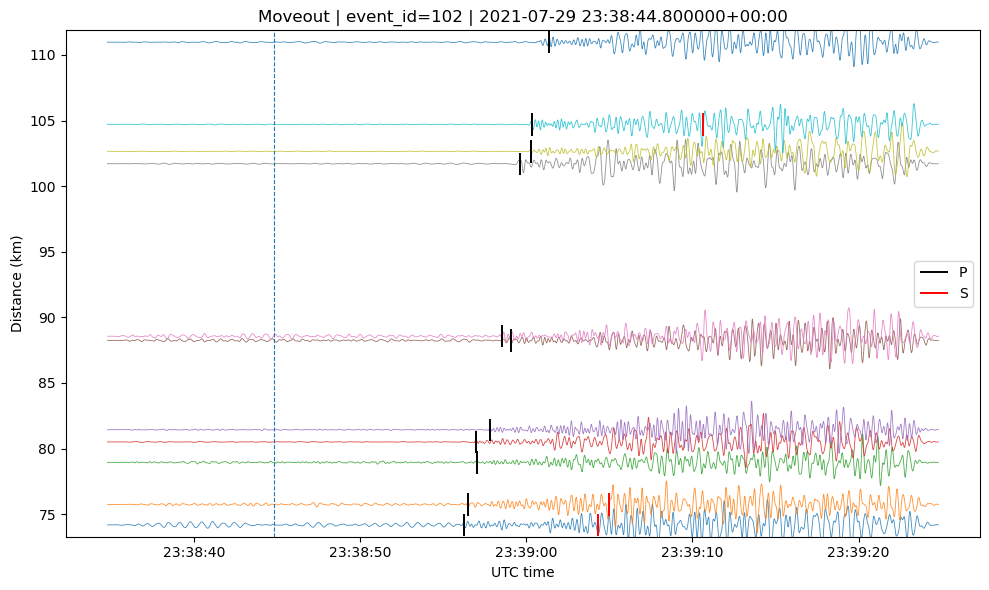

In [18]:
for row_idx, row_event in catalog_df.iloc[0:1].iterrows():
    fig, ax, meta = h.plot_event_moveout_picks_only(
        row_event=row_event,
        picks=picks_df,
        stations=stations_df,
        cache=stream_cache,
        wf_index=wf_index,
        pre_s=10,
        post_s=40,
        freqmin=1.0,
        freqmax=5.0,
        p_color="black",
        s_color="red",
        line_height_km=1.7,
        line_width=1.4,
        wiggle_frac_of_spacing=1.2,
    )
    print(row_idx, "files:", [Path(f).name for f in meta["files"]], "stations:", len(meta["stations_used"]))


SPECTROGRAM

/home/elizabeth/soft/src/QuickQuake/quickquake/qq_helpers.py:992: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



files: ['2021-07-29T08-00-00.mseed', '2021-07-29T16-00-00.mseed']
stations used: 11


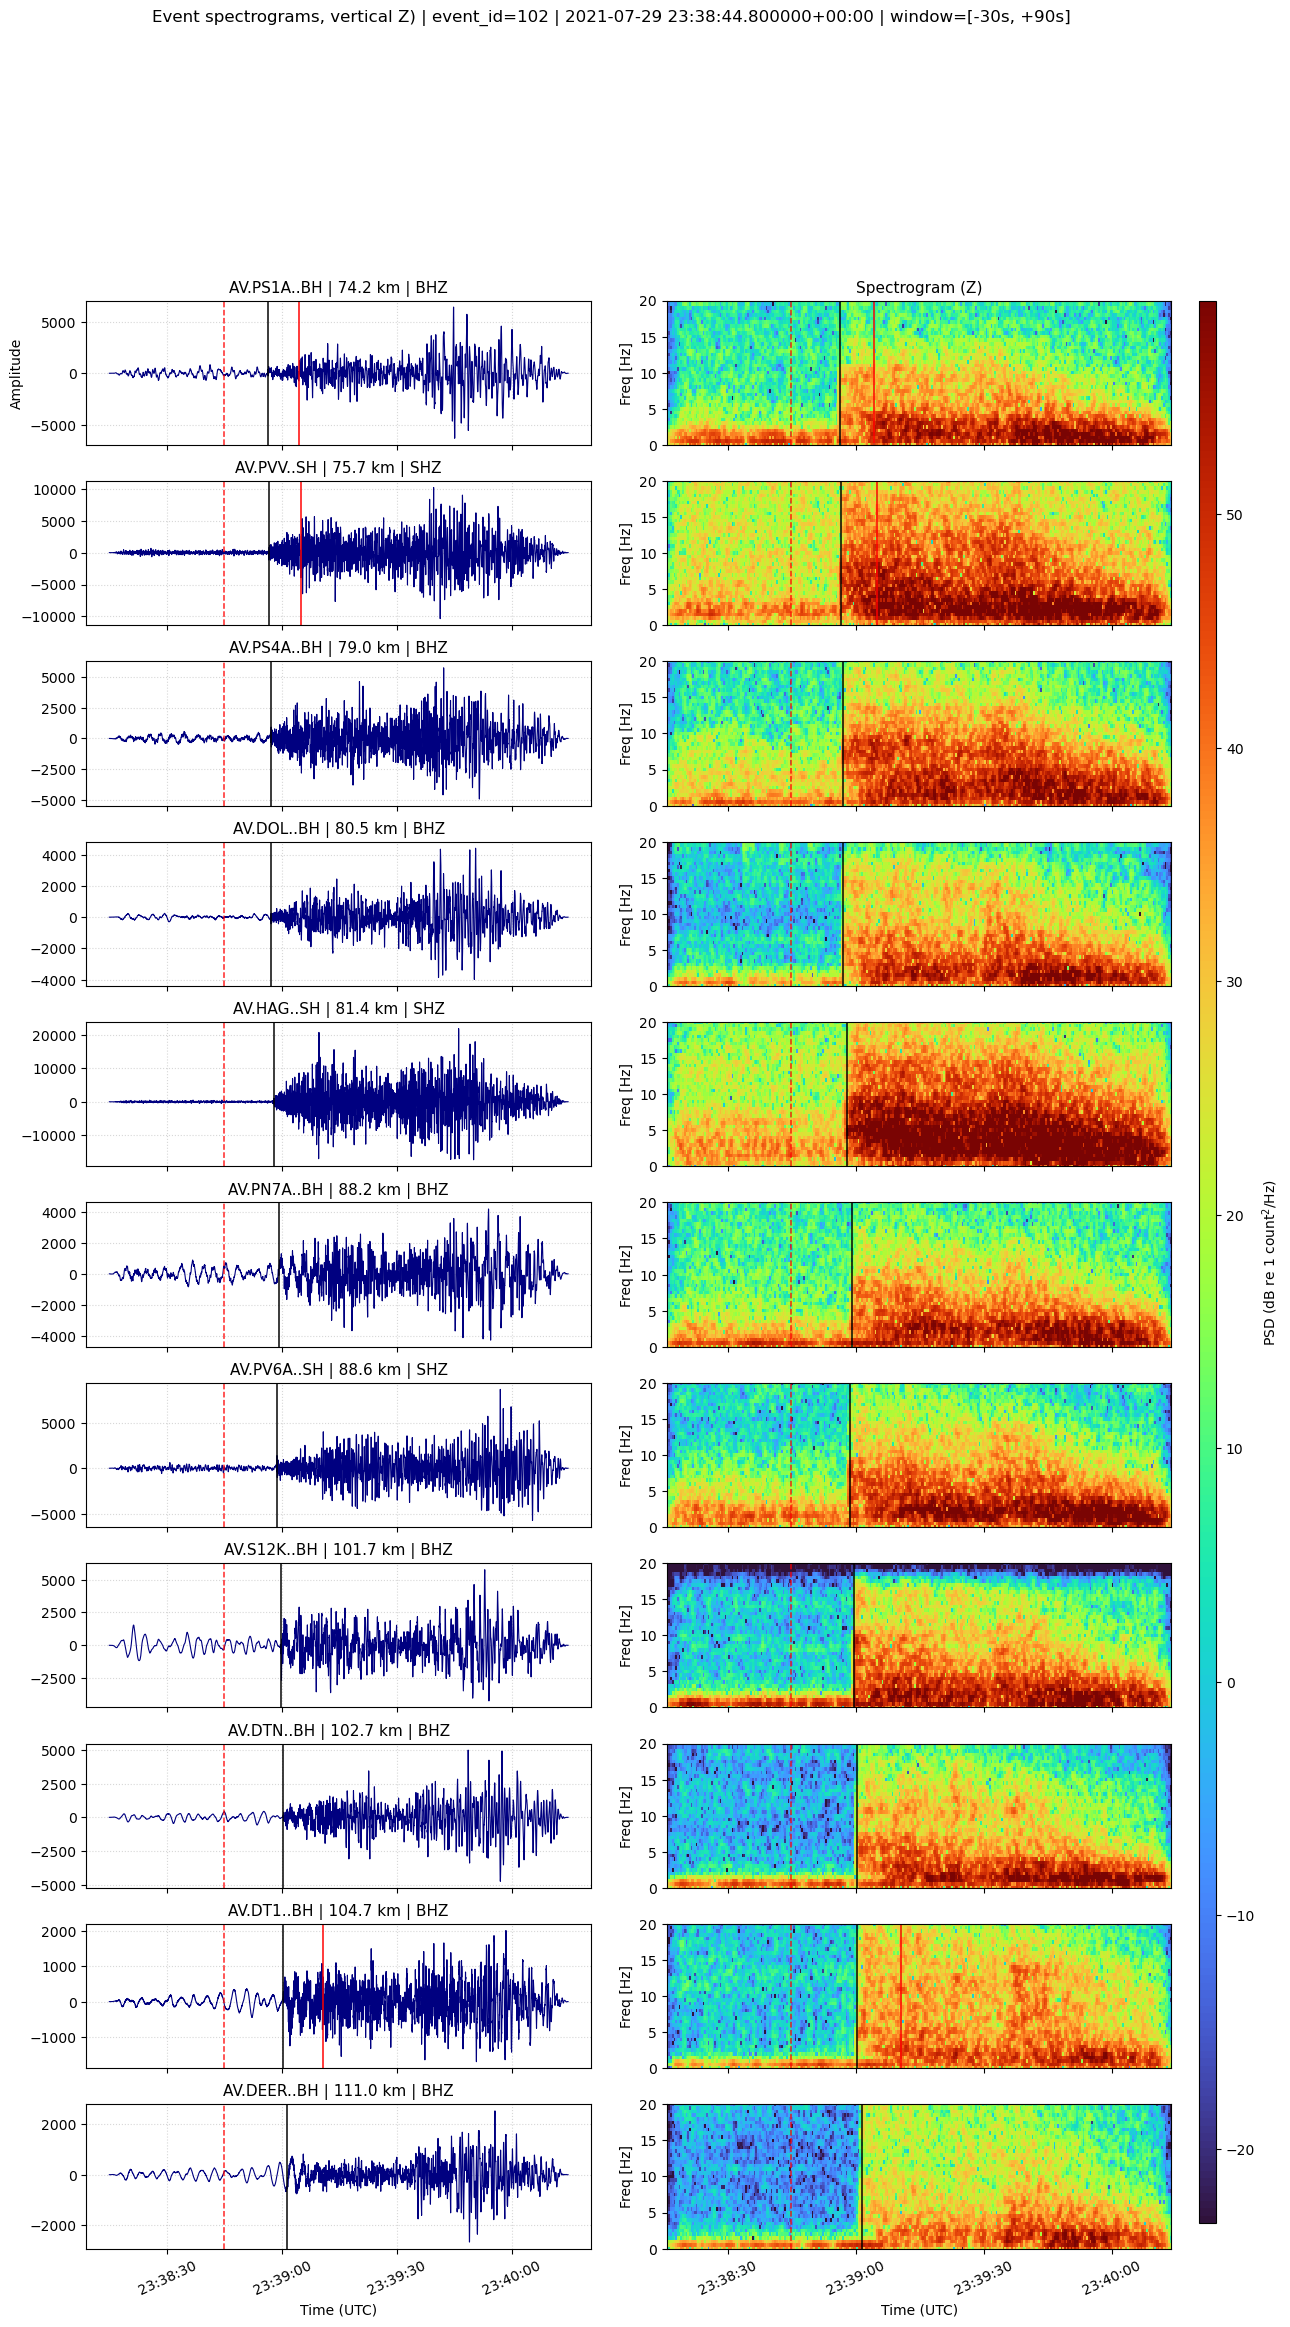

In [19]:
for row_idx, row_event in catalog_df.iloc[0:1].iterrows():
    fig, axes, meta = h.plot_event_spectrograms_vertical_picks_only(
        row_event=row_event,
        picks=picks_df,
        stations=stations_df,
        cache=stream_cache,
        wf_index=wf_index,
        pre_s=30,
        post_s=90,
        window_s=2,
        overlap_frac=0.8,
        freq_min=0,
        freq_max=20,
    )
    print("files:", [Path(f).name for f in meta["files"]])
    print("stations used:", len(meta["stations_used"]))


Pavlof seismicity map from 2021-01-01 to 2021-12-31 (Size = Magnitude | Color = Depth)


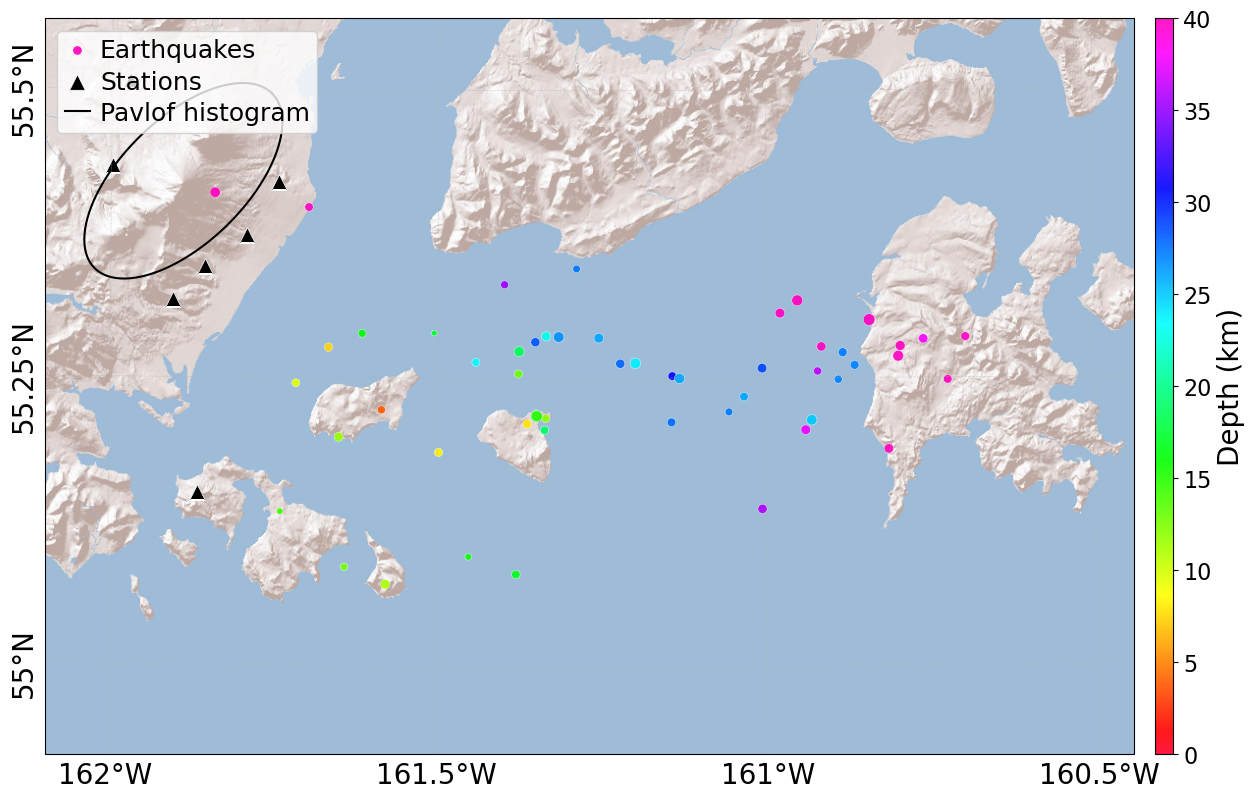

(<Figure size 1500x800 with 2 Axes>, <GeoAxes: >)

In [35]:
start_2021 = "2021-01-01T00:00:00Z"
end_2021   = "2021-12-31T23:59:59Z"

h.plot_mapview_seismicity(
    catalog=catalog_df,
    stations=stations_df,
    start=start_2021,
    end=end_2021,
    relief_zoom=12,
    savefig=False,
    ellipse_lon=-161.89, ellipse_lat=55.42,
    a_km=12, b_km=6, theta_deg=45,
)

Número de eventos después de filtros (time, depth<=40 km): 41


grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -161.739372 to -161.741666667
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -160.760986 to -160.758333333
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 55.07039 to 55.0666666667
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 55.344958 to 55.3458333333


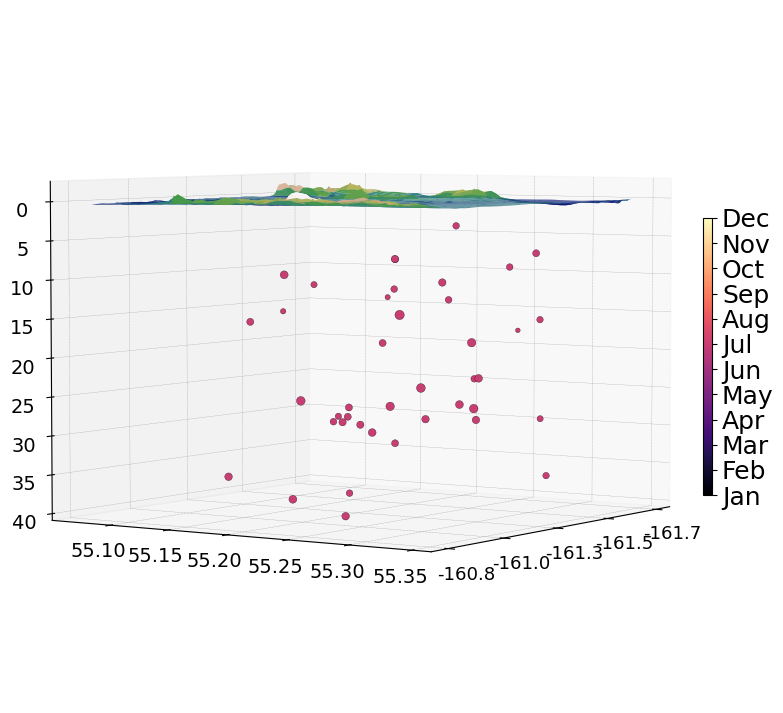

Number of plotted seismic events: 41


In [43]:
import matplotlib.pyplot as plt
import qq_helpers as h

fig, ax, meta = h.plot_mapview3d_months(
    catalog=catalog_df,          # el mismo catálogo que vienes usando
    start="2021-01-01",
    end="2022-01-01",            # end exclusivo (como tu script)
    depth_max=40,
    exagg=4,
    view_elev=4,
    view_azim=34,
    dem_res="15s",
    savefig=False,               # no guarda por defecto
)

plt.show()
print("Number of plotted seismic events:", meta["n_events"])

In [9]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"   # o "vscode" si estás en VSCode

fig = h.plot_catalog_3d_topo_seismicity(
    catalog=catalog,
    mode="time",
    show=True,   
)



/home/elizabeth/anaconda3/envs/seisgo/lib/python3.9/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.


grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -161.841406 to -161.841666667
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -160.696973 to -160.695833333
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 55.07039 to 55.0666666667
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 55.410327 to 55.4125


In [10]:
fig = h.plot_catalog_3d_topo_seismicity(
    catalog=catalog,
    mode="year_month",
    year=2021,
    show=True,
)


grdcut [WARNING]: (w - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: w reset from -161.841406 to -161.841666667
grdcut [WARNING]: (e - x_min) must equal (NX + eps) * x_inc), where NX is an integer and |eps| <= 0.0001.
grdcut [WARNING]: e reset from -160.696973 to -160.695833333
grdcut [WARNING]: (s - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: s reset from 55.07039 to 55.0666666667
grdcut [WARNING]: (n - y_min) must equal (NY + eps) * y_inc), where NY is an integer and |eps| <= 0.0001.
grdcut [WARNING]: n reset from 55.410327 to 55.4125


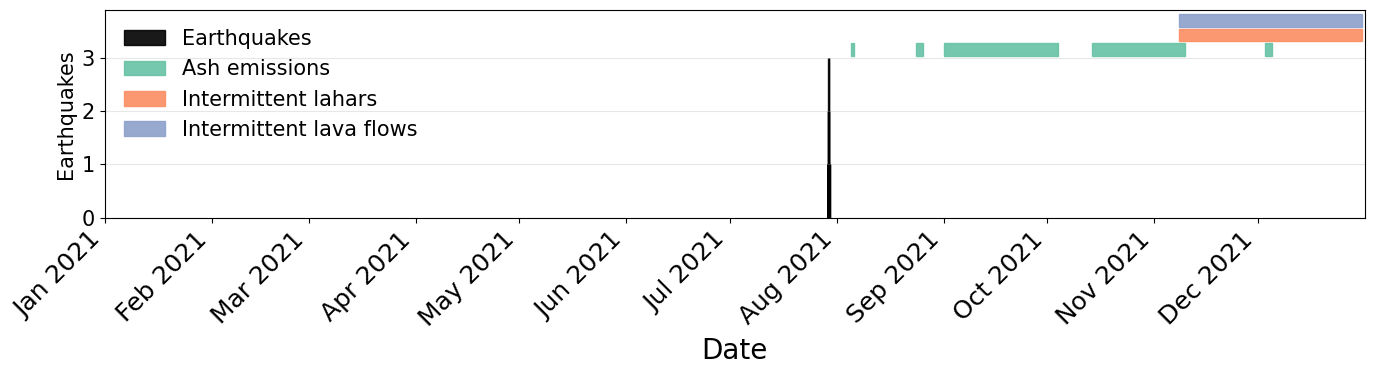

In [40]:
# 1) El usuario edita esto (por región / por año / etc.)
event_spans = [
    ("2021-08-05", "2021-08-06", "Ash emissions"),
    ("2021-08-24", "2021-08-26", "Ash emissions"),
    ("2021-09-01", "2021-10-04", "Ash emissions"),
    ("2021-10-14", "2021-11-10", "Ash emissions"),
    ("2021-12-03", "2021-12-05", "Ash emissions"),
    ("2021-11-08", "2021-12-31", "Intermittent lahars"),
    ("2021-11-08", "2021-12-31", "Intermittent lava flows"),
]

# 2) 1 sola línea de plotting (NO guarda png por defecto)
fig, ax, meta = h.plot_timeline_histogram(
    catalog=catalog_df,         # o dataquake si usas el CSV de elipse
    start=start_2021,
    end=end_2021,
    spans=event_spans,
    n_bins=90,
    savefig=False,              # <-- clave: no guardar a menos que tú lo pidas
)
plt.show()